In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

df_alpha = pd.read_csv('alpha_martinez.csv',names=['current','alpha'])

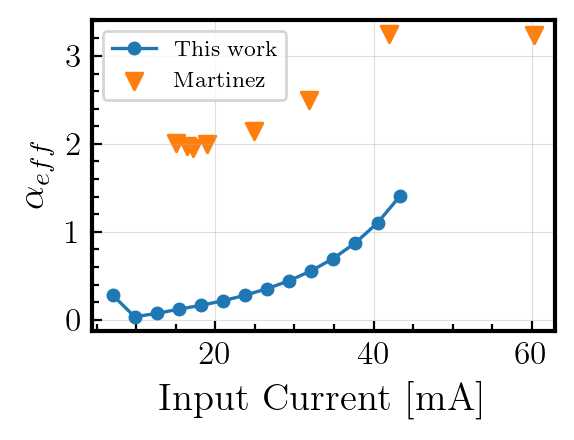

Plot saved as C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\pgf_figures\LEF_vs_current.pgf and .\LEF_vs_current.png


In [9]:
# ── Figure sizing (golden ratio, single-column width) ──────────────────────
GOLDEN_RATIO = 1.618
FIG_WIDTH_IN = 3.1                     # comfortably under the 6.3 in max
FIG_HEIGHT_IN = 2.3

# ── Publication-style rcParams ──────────────────────────────────────────────
maj_tick_width = 0.8
min_tick_width = 0.8

plot_params = {
    "figure.dpi": 200,
    "axes.labelsize": 14,
    "axes.linewidth": 1.5,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.title_fontsize": 11,
    "legend.fontsize": 11,
    "xtick.major.size": 3.5,
    "xtick.major.width": maj_tick_width,
    "xtick.minor.size": 2.5,
    "xtick.minor.width": min_tick_width,
    "ytick.major.size": 3.5,
    "ytick.major.width": maj_tick_width,
    "ytick.minor.size": 2.5,
    "ytick.minor.width": min_tick_width,
    "font.family": "serif",
    "text.usetex": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pgf.texsystem": "pdflatex",
    "pgf.rcfonts": False,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}

plt.rcParams.update(plot_params)
# Default simulation parameters matching your blueprint setup
PARAMS = {
    'q': 1.602e-19,             # Elementary charge
    'eta': 3.4,                 # Refractive index of background material
    'N_l': 5.0                  # Number of QD layers
}

# ── Load and Parse Data ───────────────────────────────────────────────────
folder_path = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else "."
csv_files = glob.glob(os.path.join(folder_path, "alpha_freq_data_*mA.csv"))

data = []
for file_path in csv_files:
    filename = os.path.basename(file_path)
    match = re.search(r"alpha_freq_data_([\d.]+)mA\.csv", filename)
    if match:
        current = float(match.group(1))
        df = pd.read_csv(file_path)
        # Extract the final alpha value (last row in 'Alpha' column)
        final_alpha = df['Alpha'].iloc[-1]
        data.append({'current': current, 'final_alpha': final_alpha})

df_plot = pd.DataFrame(data).sort_values('current')

# ── Plotting ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

ax.plot(df_plot['current'][:-6], df_plot['final_alpha'][:-6], color="tab:blue", marker="o", markersize=4, linewidth=1.2, label=r"This work")

ax.set_xlabel("Input Current [mA]")
ax.set_ylabel(r"$\alpha_{eff}$")
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.set_yscale('linear')

fig.tight_layout()

# Save output files
pdf_path = os.path.join(r'C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\pgf_figures', "LEF_vs_current.pgf")
png_path = os.path.join(folder_path, "LEF_vs_current.png")

plt.scatter(df_alpha['current'],df_alpha['alpha'],marker='v',color='C1',label='Martinez')
plt.legend(fontsize=8)
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")
plt.show()
print(f"Plot saved as {pdf_path} and {png_path}")
